# Import Library and Dataset

In [41]:
import os
import requests
import tarfile
import time
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, random_split ,Subset
import torchvision.models as models
import torch.nn as nn
import torch
import PIL.Image
import pathlib
from torchsummary import summary
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import torch.optim as optim
import pandas as pd
from torchvision.transforms import functional as TF
import timm
from transformers import AutoImageProcessor, AutoModelForImageClassification

from torch.cuda.amp import autocast, GradScaler # Mixed Precision


In [42]:
if torch.cuda.is_available():
    device = "cuda" # Use NVIDIA GPU (if available)
elif torch.backends.mps.is_available():
    device = "mps" # Use Apple Silicon GPU (if available)
else:
    device = "cpu" # Default to CPU if no GPU is available

# Load Dataset

In [6]:
# Install gdown if not already available
!pip install --quiet gdown

# Import and download file
import gdown

# Google Drive file ID
file_id = "10Y65ykpja1t6UWt3imPPbZkqhe0kOPL9"
url = f"https://drive.google.com/uc?id={file_id}"

# Output filename (change if needed)
output = "Animals_Dataset_v1.zip"

# Download
gdown.download(url, output, quiet=False)

print("Download completed:", output)



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


Downloading...
From (original): https://drive.google.com/uc?id=10Y65ykpja1t6UWt3imPPbZkqhe0kOPL9
From (redirected): https://drive.google.com/uc?id=10Y65ykpja1t6UWt3imPPbZkqhe0kOPL9&confirm=t&uuid=74712759-506b-4576-b55f-0c64799cb9e7
To: /home/Animals_Dataset_v1.zip
100%|██████████| 643M/643M [00:08<00:00, 76.4MB/s] 

Download completed: Animals_Dataset_v1.zip


In [5]:
!gdown --fuzzy https://drive.google.com/file/d/10Y65ykpja1t6UWt3imPPbZkqhe0kOPL9/view?usp=sharing # new url v1
#!gdown --fuzzy https://drive.google.com/file/d/1uc7uQ5myz7k74ZO460Q04B35_GekQeGi/view?usp=sharing # new url v2



zsh:1: no matches found: https://drive.google.com/file/d/10Y65ykpja1t6UWt3imPPbZkqhe0kOPL9/view?usp=sharing


In [7]:
!unzip -q Animals_Dataset_v1.zip

# Construct Dataset and DataLoader

In [50]:
import torchvision.transforms.v2 as v2
from torchvision.transforms import AutoAugment, AutoAugmentPolicy
import torchvision.transforms as transforms
seed = 1000
torch.manual_seed(seed)

'''
Random Resize Crop : https://www.geeksforgeeks.org/python/randomresizedcrop-method-in-python-pytorch/
Horizontal Flip : https://www.geeksforgeeks.org/python/python-pytorch-randomhorizontalflip-function/
Auto Augment : https://sebastianraschka.com/blog/2023/data-augmentation-pytorch.html
Auto Augment : https://docs.pytorch.org/vision/main/generated/torchvision.transforms.AutoAugment.html
'''

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]


processor = AutoImageProcessor.from_pretrained('facebook/dinov2-with-registers-giant-imagenet1k-1-layer')


# Training Data Augmentation
train_transform = transforms.Compose([
        # Resize
        transforms.Resize(256),
        # Random Crop 
        transforms.RandomResizedCrop(size = 224 , scale =(0.08,1) , ratio =(3/4 , 4/3)),
        # Random Augment
        transforms.RandAugment(interpolation=transforms.InterpolationMode.BILINEAR,num_ops=1),
        # Auto Augment
        transforms.AutoAugment(policy = AutoAugmentPolicy.IMAGENET),
        # Horizontal Flip
        transforms.RandomHorizontalFlip(p=0.5),
        # Color Jitter
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1 , hue = 0.02),
        # Convert to Tensor
        #transforms.ToTensor(),
        transforms.Lambda(lambda img: processor(images=img, return_tensors="pt")["pixel_values"].squeeze(0)),
        #Normalize
        #transforms.Normalize(mean=mean,std=std),
        # Random Erasion
        transforms.RandomErasing(p=0.1),
                                      ])
# Validation Data Augmentation
val_transform = transforms.Compose([
        # Resize
        transforms.Resize(256),
        # Random Crop 
        #transforms.CenterCrop(size = 224),
        #transforms.ToTensor(),
        transforms.Lambda(lambda img: processor(images=img, return_tensors="pt")["pixel_values"].squeeze(0)),
        #transforms.Normalize(mean=mean,std=std)
])


# Load the dataset using torchvision.datasets.ImageFolder and apply transformations
data_dir = "./FIT5215_Dataset"
full_dataset = datasets.ImageFolder(data_dir)

# Split
train_size = int(0.9 * len(full_dataset))
val_size   = len(full_dataset) - train_size
train_subset, val_subset = random_split(full_dataset, [train_size, val_size])

# Re-wrap with transforms
train_dataset = datasets.ImageFolder(data_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(data_dir, transform=val_transform)

# Apply same indices from split
train_dataset = Subset(train_dataset, train_subset.indices)
val_dataset   = Subset(val_dataset, val_subset.indices)

# DataLoaders

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False,
                          num_workers=4, pin_memory=True)
print("Number of instance in train_set: %s" % len(train_dataset))
print("Number of instance in val_set: %s" % len(val_dataset))

Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 9404.27it/s]

Number of instance in train_set: 8519
Number of instance in val_set: 947


# Visualize Training Data

In [51]:
class_names = ['birds', 'bottles', 'breads', 'butterflies', 'cakes', 'cats', 'chickens', 'cows', 'dogs', 'ducks',
                  'elephants', 'fishes', 'handguns', 'horses', 'lions', 'lipsticks', 'seals', 'snakes', 'spiders', 'vases']

In [52]:
# obtain one batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images.numpy() # convert images to numpy for display

In [53]:
import math

def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    plt.imshow(np.transpose(img, (1, 2, 0)))  # convert from Tensor image

def visualize_data(images, categories, images_per_row = 8):
    class_names = ['birds', 'bottles', 'breads', 'butterflies', 'cakes', 'cats', 'chickens', 'cows', 'dogs', 'ducks',
                  'elephants', 'fishes', 'handguns', 'horses', 'lions', 'lipsticks', 'seals', 'snakes', 'spiders', 'vases']
    n_images = len(images)
    n_rows = math.ceil(float(n_images)/images_per_row)
    fig = plt.figure(figsize=(1.5*images_per_row, 1.5*n_rows))
    fig.patch.set_facecolor('white')
    for i in range(n_images):
        plt.subplot(n_rows, images_per_row, i+1)
        plt.xticks([])
        plt.yticks([])
        imshow(images[i])
        class_index = categories[i]
        plt.xlabel(class_names[class_index])
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.7502832].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.13083315..0.30366015].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.6979957].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5418272..1.6805664].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.46476585..1.1576908].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.6

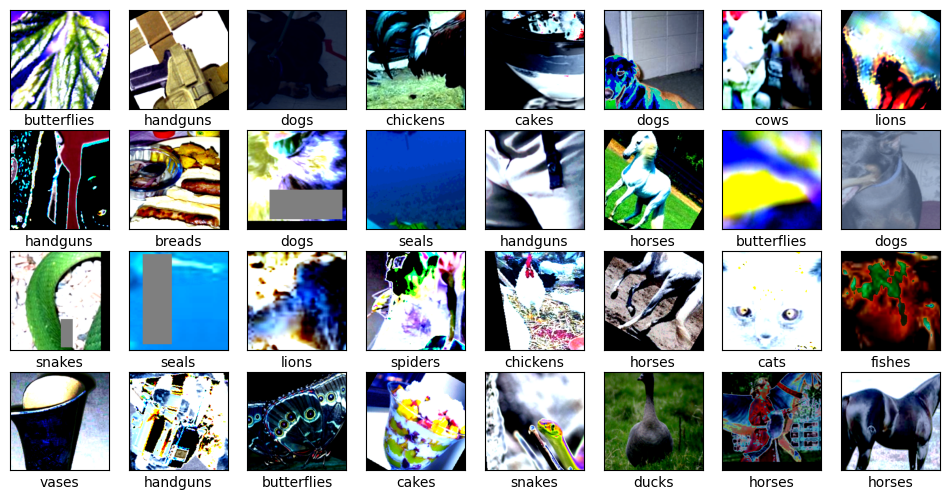

In [54]:
visualize_data(images, labels)

# Beit Image Processor

In [34]:


processor = AutoImageProcessor.from_pretrained('facebook/dinov2-with-registers-giant-imagenet1k-1-layer')

print(processor)

Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 6932.73it/s]

BitImageProcessor {
  "crop_size": {
    "height": 224,
    "width": 224
  },
  "do_center_crop": true,
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "BitImageProcessor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 256
  }
}



# Beit Transformer

In [37]:
#https://huggingface.co/microsoft/beit-base-patch16-224-pt22k-ft22k
model = AutoModelForImageClassification.from_pretrained('facebook/dinov2-with-registers-giant-imagenet1k-1-layer')
model.classifier = nn.Linear(in_features=3072, out_features=20, bias=True)
#model = model.eval()
print(model)

Dinov2WithRegistersForImageClassification(
  (dinov2_with_registers): Dinov2WithRegistersModel(
    (embeddings): Dinov2WithRegistersEmbeddings(
      (patch_embeddings): Dinov2WithRegistersPatchEmbeddings(
        (projection): Conv2d(3, 1536, kernel_size=(14, 14), stride=(14, 14))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): Dinov2WithRegistersEncoder(
      (layer): ModuleList(
        (0-39): 40 x Dinov2WithRegistersLayer(
          (norm1): LayerNorm((1536,), eps=1e-06, elementwise_affine=True)
          (attention): Dinov2WithRegistersAttention(
            (attention): Dinov2WithRegistersSelfAttention(
              (query): Linear(in_features=1536, out_features=1536, bias=True)
              (key): Linear(in_features=1536, out_features=1536, bias=True)
              (value): Linear(in_features=1536, out_features=1536, bias=True)
            )
            (output): Dinov2WithRegistersSelfOutput(
              (dense): Linear(in_features=1536, out_f

In [38]:
model.classifier

Linear(in_features=3072, out_features=20, bias=True)

In [39]:
for idx ,(name, param) in enumerate(model.named_parameters()):
    print(idx , name)


0 dinov2_with_registers.embeddings.cls_token
1 dinov2_with_registers.embeddings.mask_token
2 dinov2_with_registers.embeddings.register_tokens
3 dinov2_with_registers.embeddings.position_embeddings
4 dinov2_with_registers.embeddings.patch_embeddings.projection.weight
5 dinov2_with_registers.embeddings.patch_embeddings.projection.bias
6 dinov2_with_registers.encoder.layer.0.norm1.weight
7 dinov2_with_registers.encoder.layer.0.norm1.bias
8 dinov2_with_registers.encoder.layer.0.attention.attention.query.weight
9 dinov2_with_registers.encoder.layer.0.attention.attention.query.bias
10 dinov2_with_registers.encoder.layer.0.attention.attention.key.weight
11 dinov2_with_registers.encoder.layer.0.attention.attention.key.bias
12 dinov2_with_registers.encoder.layer.0.attention.attention.value.weight
13 dinov2_with_registers.encoder.layer.0.attention.attention.value.bias
14 dinov2_with_registers.encoder.layer.0.attention.output.dense.weight
15 dinov2_with_registers.encoder.layer.0.attention.output.

In [40]:
# Freeze Parameters Except Few Last Layers

param_list = []
for idx ,(name, param) in enumerate(model.named_parameters()):
    if idx < 708:
        param.requires_grad = False

    else:
        param.requires_grad = True
        param_list.append(param)

optimizer = optim.SGD(param_list, lr=0.001, momentum=0.9, weight_decay =1e-4 , nesterov = True)

In [55]:
import numpy as np

def top_k_accuracy(output, target, k=5):
    batch_size = target.size(0)
    _, pred = output.topk(k, 1, True, True)  # Get top-k predictions
    pred = pred.t()  # Transpose predictions for comparison
    correct = pred.eq(target.reshape(1, -1).expand_as(pred))  # Compare predictions with target
    correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)  # Calculate correct top-k
    return correct_k.mul_(1.0 / batch_size).item()  # Calculate top-k accuracy

class BaseTrainer:
    def __init__(self, model, criterion, optimizer, train_loader, val_loader ,device,random_seed,train_percent ,random_augment_ops,rand_epoch):
        self.model = model.to(device)
        self.criterion = criterion
        self.optimizer = optimizer
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.stop_training = False
        self.random_seed = random_seed
        self.train_percent = train_percent
        self.random_augment_ops = random_augment_ops
        self.rand_epoch = rand_epoch

        # Mixed Precision Training
        self.scaler = GradScaler()
    def fit(self, num_epochs):
        self.num_batches = len(self.train_loader)
        best_val_loss = float('inf')
        for epoch in range(num_epochs):
            if self.stop_training:
                break
            print(f'Epoch {epoch + 1}/{num_epochs}')
            start_time = time.time()
            train_loss, train_accuracy = self.train_one_epoch()
            val_loss, top1_acc, top5_acc = self.validate_one_epoch()
            print(
                f' train_loss: {train_loss:.4f} - train_accuracy: {train_accuracy:.4f} - val_loss: {val_loss:.4f} - top1_acc: {top1_acc:.4f} - top5_acc: {top5_acc:.4f}'
            )
            self.on_epoch_end({'epoch': epoch, 'train_loss': train_loss, 'train_accuracy': train_accuracy, 'val_loss': val_loss, 'val_accuracy': top1_acc, 'top5_acc': top5_acc})

            if val_loss <  best_val_loss:
                save_path = f"models/Register_Dino_Random_Large_seed{self.random_seed}_train{self.train_percent}_aug{self.random_augment_ops}_epoch{self.rand_epoch}.pth"
                torch.save(self.model.state_dict(), save_path)


    def train_one_epoch(self):
        self.model.train()
        running_loss, correct, total = 0.0, 0, 0

        for i, data in enumerate(self.train_loader):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            ##### Probability Getting Cutmix End
            self.optimizer.zero_grad()

            # Mixed Precision Training
            with autocast( dtype=torch.float16):
                outputs = self.model(inputs)
                outputs = outputs.logits
                loss = self.criterion(outputs, labels)
            
            
            self.scaler.scale(loss).backward()
            self.scaler.step(self.optimizer)
            
            #loss.backward()
            #self.optimizer.step()
            self.scaler.update()

            running_loss += loss.item()

            # Accuracy Calculation Cutmix
            if labels.ndim == 2:
                hard_label = torch.argmax(labels,dim=1)
            else:
                hard_label = labels
            _, predicted = torch.max(outputs.data, 1)
            total += hard_label.size(0)
            correct += (predicted == hard_label).sum().item()

        train_accuracy = correct / total
        train_loss = running_loss / self.num_batches
        return train_loss, train_accuracy

    def validate_one_epoch(self):
        self.model.eval()
        val_loss, correct, total_top1_acc, total_top5_acc, total = 0.0, 0, 0.0, 0.0, 0
        with torch.no_grad():
            for data in self.val_loader:
                inputs, labels = data
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = self.model(inputs)
                outputs = outputs.logits
                loss = self.criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                correct += (predicted == labels).sum().item()

                top1_acc = top_k_accuracy(outputs, labels, k=1)
                top5_acc = top_k_accuracy(outputs, labels, k=5)

                total_top1_acc += top1_acc * inputs.size(0)  # Custom evaluation metric
                total_top5_acc += top5_acc * inputs.size(0)  # Custom evaluation metric
                total += labels.size(0)

        val_loss /= len(self.val_loader)
        top1_acc = total_top1_acc / total
        top5_acc = total_top5_acc / total
        return val_loss, top1_acc, top5_acc

    def on_epoch_end(self, params):
        pass

In [56]:
# Since i am continuing Training , i Load my Best Model


#optimizer = optim.SGD(param_list, lr=0.001, momentum=0.9, weight_decay =1e-4 , nesterov = True)
#model = timm.create_model('vit_large_patch14_clip_224.openai_ft_in12k_in1k', pretrained=True)
#model.head = nn.Linear(in_features=1024, out_features=20, bias=True)
#model.load_state_dict(torch.load("./models/timm_vit_large_v2.pth"))
#model = BeitForImageClassification.from_pretrained('microsoft/beit-base-patch16-224-pt22k-ft22k')
#model.classifier = nn.Linear(in_features=768, out_features=20, bias=True)
#model.load_state_dict(torch.load("./models/beit.pth"))
# Freeze Parameters Except Few Last Layers
#model = BeitForImageClassification.from_pretrained('microsoft/beit-base-patch16-224-pt22k-ft22k')
#model.classifier = nn.Linear(in_features=768, out_features=20, bias=True)
#model.load_state_dict(torch.load("./models/beit_fixed_seed.pth"))

#param_list = []
#for idx ,(name, param) in enumerate(model.named_parameters()):
#    if idx < 201:
#        param.requires_grad = False

#    else:
#        param.requires_grad = True
#        param_list.append(param)

#optimizer = optim.SGD(param_list, lr=0.001, momentum=0.9, weight_decay =1e-4 , nesterov = True)

In [ ]:
if torch.cuda.is_available():
    device = "cuda" # Use NVIDIA GPU (if available)
elif torch.backends.mps.is_available():
    device = "mps" # Use Apple Silicon GPU (if available)
else:
    device = "cpu" # Default to CPU if no GPU is available

model.to(device)
criterion = nn.CrossEntropyLoss()
train_percent = np.random.choice([0.8,0.9]).item()
random_augment_ops = np.random.choice([1,2]).item()
epoch_num = np.random.choice([27,28,29,30]).item()
trainer = BaseTrainer(model, criterion, optimizer, train_loader, val_loader ,device,random_seed = seed,train_percent = train_percent ,random_augment_ops = random_augment_ops,rand_epoch=epoch_num)
trainer.fit(num_epochs=20)

Epoch 1/20


/tmp/ipykernel_95/2784038616.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler()
/tmp/ipykernel_95/2784038616.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast( dtype=torch.float16):


In [20]:
torch.cuda.empty_cache()


In [21]:
print('test')

test


# Save and Upload Result

In [17]:
#!unzip -q fit-5215-object-detection-s-2-2025.zip



In [22]:
from tqdm import tqdm
def save_prediction_to_csv(model, loader, device, output_file="SubmissionDino_random_1_giant.csv"):
    model.eval()
    predictions = []
    image_ids = []
    df = {
    "ID": [],
    "Label": []
    }
    total = 0
    with torch.no_grad():
        for i, (batchX, batchY) in tqdm(enumerate(loader)):
            batchX, batchY = batchX.to(device), batchY.to(device)
            outputs = model(batchX.float())  # Convert to float32 and feed batch to the model
            outputs = outputs.logits
            predicted = torch.argmax(outputs, dim=1)  # Get the predicted class
            total += predicted.size(0)
            for ids, pred in enumerate(predicted):
                label = class_names[pred.to(device).item()]
                df["ID"].append(i*500+ids)
                df["Label"].append(label)
    df["ID"] = [i for i in range(total)]
    # Create a DataFrame
    df = pd.DataFrame(df)
    # Save to CSV
    df.to_csv(output_file, index=False)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5178571..1.7142857].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5178571..1.6244541].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping input 

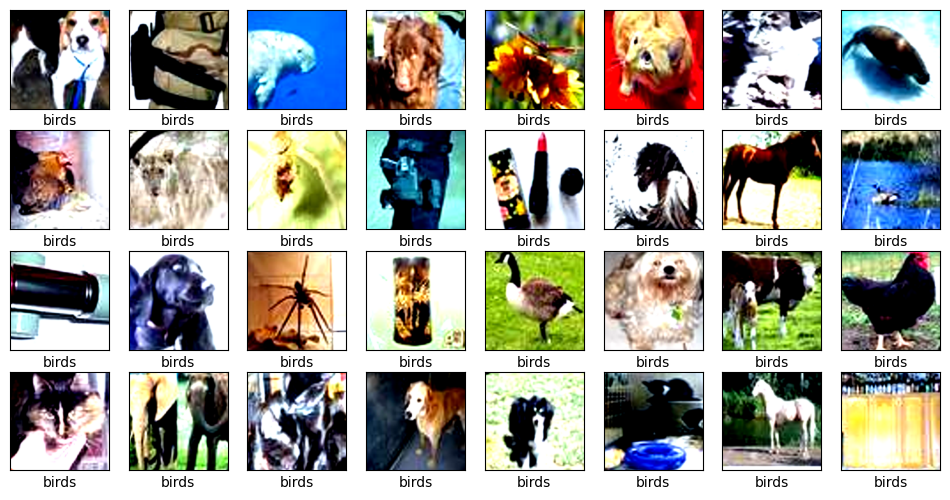

"\nimg = image[11]\nimg_np = img.permute(1, 2, 0).cpu().numpy()\n\nplt.figure(figsize=(8, 8))\nplt.imshow(img_np)\nplt.axis('off')\nplt.title(f'Test Image (Label: {labels})')\nplt.show()\n"

In [23]:
transform_test_Data = transforms.Compose([
        transforms.Lambda(lambda img: processor(images=img, return_tensors="pt")["pixel_values"].squeeze(0))])


test_dir = "./test_set"
test_dataset = datasets.ImageFolder(test_dir , transform = transform_test_Data)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
test_iter = iter(test_loader)
image , labels = next(test_iter)

visualize_data(image, labels)


'''
img = image[11]
img_np = img.permute(1, 2, 0).cpu().numpy()

plt.figure(figsize=(8, 8))
plt.imshow(img_np)
plt.axis('off')
plt.title(f'Test Image (Label: {labels})')
plt.show()
'''

In [24]:
model = AutoModelForImageClassification.from_pretrained('facebook/dinov2-giant-imagenet1k-1-layer')
model.classifier = nn.Linear(in_features=3072, out_features=20, bias=True)
model.load_state_dict(torch.load("./models/Dino_random_1_giant.pth"))

<All keys matched successfully>

In [25]:
if torch.cuda.is_available():
    device = "cuda" # Use NVIDIA GPU (if available)
elif torch.backends.mps.is_available():
    device = "mps" # Use Apple Silicon GPU (if available)
else:
    device = "cpu" # Default to CPU if no GPU is available
    
model.to(device)
save_prediction_to_csv(model, test_loader, device, output_file="SubmissionDino_random_1_giant.csv")
df =  pd.read_csv('SubmissionDino_random_1_giant.csv')
df

506it [14:23,  1.71s/it]


,ID,Label
0,0,dogs
1,1,handguns
2,2,seals
3,3,dogs
4,4,butterflies
...,...,...
16162,16162,spiders
16163,16163,spiders
16164,16164,ducks
16165,16165,ducks
